# Material Classification from Multipath Profiles


## Package Requirements


In [2]:

# Uncomment only if you are missing packages.
#
%pip install numpy scipy matplotlib torch


Note: you may need to restart the kernel to use updated packages.


# 1. Imports and Configuration

The imports below include standard Python libraries, numerical tools, MATLAB loading tools, plotting tools, and PyTorch.


In [3]:

from pathlib import Path
from typing import Any, Dict, List, Tuple
import random
import re
import math

import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader, Subset

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())


PyTorch version: 2.12.1+cpu
CUDA available: False


In [4]:

SEED = 42

def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cpu


# 2. Locate the MATLAB Data



In [5]:

DATA_DIR = Path("Processed_Data_Points (missing rows)/combined/")

mat_files = sorted(DATA_DIR.glob("*.mat"))

print("Data directory:", DATA_DIR.resolve())
print("Number of .mat files found:", len(mat_files))

for path in mat_files[:5]:
    print(" ", path.name)

if len(mat_files) == 0:
    print("\nNo .mat files were found. Make sure your files are in projects/p3/data/*.mat")


Data directory: C:\Users\WINGS\Documents\Ashley\WINGS-2026\Processed_Data_Points (missing rows)\combined
Number of .mat files found: 80
  data_BW_4GHz_RF_300GHzDrywall_Angle25_Power_125.mat
  data_BW_4GHz_RF_300GHzDrywall_Angle25_Power_176.mat
  data_BW_4GHz_RF_300GHzDrywall_Angle25_Power_250.mat
  data_BW_4GHz_RF_300GHzDrywall_Angle25_Power_354.mat
  data_BW_4GHz_RF_300GHzDrywall_Angle25_Power_500.mat


# 3. Inspect a MATLAB File

MATLAB files store named variables. When we use `loadmat`, Python returns a dictionary:

```python
mat = loadmat(path)
```

The keys are variable names. The values are arrays or MATLAB-like objects converted into Python objects.

Before building a dataset, always inspect the file. This is one of the most important research habits.


In [15]:

KEYWORDS = [
    "multipath", "path", "profile", "pdp", "peak", "delay", "tau",
    "time", "corr", "if", "rms", "k", "power", "sig", "distance", "angle"
]

def is_interesting_key(key: str) -> bool:
    """Return True if a MATLAB variable name looks relevant to this project."""
    key_lower = key.lower()
    return any(word in key_lower for word in KEYWORDS)

def inspect_mat_file(path: Path, max_keys: int = 100):
    """Print variable names, shapes, and dtypes from one .mat file."""
    mat = loadmat(path, squeeze_me=False, struct_as_record=False)

    keys = [k for k in mat.keys() if not k.startswith("__")]

    print("=" * 100)
    print("FILE:", path.name)
    print("=" * 100)

    print("\nMATLAB variables:")
    for key in keys[:max_keys]:
        arr = np.asarray(mat[key])
        marker = "  <-- likely relevant" if is_interesting_key(key) else ""
        print(f"  {key:40s} shape={str(arr.shape):18s} dtype={arr.dtype}{marker}")

    if len(keys) > max_keys:
        print(f"... skipped {len(keys) - max_keys} additional keys")

    return mat

if mat_files:
    first_mat = inspect_mat_file(mat_files[0])
else:
    first_mat = None


FILE: data_BW_4GHz_RF_300GHzDrywall_Angle25_Power_125.mat

MATLAB variables:
  K_dB                                     shape=(1, 48)            dtype=float64  <-- likely relevant
  Multipath_Profile_X_corr_IF              shape=(44, 12501)        dtype=float64  <-- likely relevant
  Multipath_Profile_X_corr_IF_complex      shape=(44, 12501)        dtype=float64  <-- likely relevant
  PDP_RMS                                  shape=(1, 48)            dtype=float64  <-- likely relevant
  P_sig_dBm                                shape=(48, 16)           dtype=float64  <-- likely relevant
  Total_distance                           shape=(1, 48)            dtype=uint8  <-- likely relevant
  distance_Rx                              shape=(1, 48)            dtype=uint8  <-- likely relevant
  distance_Tx                              shape=(1, 48)            dtype=uint8  <-- likely relevant
  peak_loc_IF                              shape=(44, 1)            dtype=object  <-- likely relevant
  p

# 4. Helper Functions for MATLAB Arrays

MATLAB arrays do not always come into Python with the exact shape we expect.

The helper below converts a MATLAB variable into a clean 2D NumPy array:

```text
rows    = examples
columns = multipath samples
```

If the data is a 1D vector, we treat it as one example.


In [16]:

def numeric_2d(value: Any) -> np.ndarray:
    """
    Convert a MATLAB numeric profile-like variable to a 2D NumPy array.

    Output shape:
        (number_of_examples, number_of_samples)
    """
    arr = np.asarray(value)

    if arr.dtype == object:
        rows = []
        for item in arr.ravel():
            item_arr = np.asarray(item).squeeze().ravel()
            if item_arr.size > 0:
                rows.append(item_arr)

        if len(rows) == 0:
            return np.empty((0, 0), dtype=np.float32)

        max_len = max(len(row) for row in rows)
        out = np.full((len(rows), max_len), np.nan, dtype=np.float32)

        for i, row in enumerate(rows):
            out[i, : len(row)] = np.asarray(row, dtype=np.float32)

        return out

    arr = np.squeeze(arr)

    if arr.ndim == 0:
        return arr.reshape(1, 1).astype(np.float32)

    if arr.ndim == 1:
        return arr.reshape(1, -1).astype(np.float32)

    if arr.ndim == 2:
        # Heuristic:
        # If one dimension is very long and the other is small, the long dimension is probably samples.
        # We want shape: (examples, samples).
        if arr.shape[0] > 1000 and arr.shape[1] < 1000:
            arr = arr.T
        return arr.astype(np.float32)

    return arr.reshape(arr.shape[0], -1).astype(np.float32)


In [17]:

def summarize_array(name: str, value: Any, preview: int = 8):
    """Print a compact summary of a MATLAB variable."""
    arr = numeric_2d(value)

    print(f"\n{name}")
    print("-" * len(name))
    print("shape:", arr.shape)
    print("dtype:", arr.dtype)

    if arr.size == 0:
        print("empty array")
        return

    finite = arr[np.isfinite(arr)]
    if finite.size > 0:
        print("min:", float(np.min(finite)))
        print("max:", float(np.max(finite)))
        print("mean:", float(np.mean(finite)))

    print(f"first {preview} values from first row:")
    print(arr[0, :preview])

if first_mat is not None:
    for key in first_mat.keys():
        if not key.startswith("__") and is_interesting_key(key):
            summarize_array(key, first_mat[key])



K_dB
----
shape: (1, 48)
dtype: float32
min: 26.742673873901367
max: 48.695091247558594
mean: 32.58213424682617
first 8 values from first row:
[31.166845 30.690777 31.643684 30.29653  28.698092 29.934229 48.69509
 46.557255]

Multipath_Profile_X_corr_IF
---------------------------
shape: (44, 12501)
dtype: float32
min: -205.49234008789062
max: -32.199981689453125
mean: -95.73307037353516
first 8 values from first row:
[ -90.53388   -89.571884  -89.285385  -89.85997   -91.68217   -95.906876
 -111.946075  -97.47285 ]

Multipath_Profile_X_corr_IF_complex
-----------------------------------
shape: (44, 12501)
dtype: float32
min: -0.0005708051612600684
max: 0.0007762486347928643
mean: -2.135708720985008e-09
first 8 values from first row:
[ 9.4038558e-07  1.0505237e-06  1.0857519e-06  1.0162520e-06
  8.2393262e-07  5.0658952e-07  7.9927496e-08 -4.2301687e-07]

PDP_RMS
-------
shape: (1, 48)
dtype: float32
min: 0.0
max: 4.4564734125174255e-09
mean: 4.3831505092128964e-10
first 8 values from 

# 5. Parse Material Labels from Filenames



In [18]:

MATERIALS = ["wood", "drywall", "glass", "metal"]

FILENAME_RE = re.compile(
    r"""
    ^data
    _BW_(?P<bw>\d+(?:\.\d+)?)GHz
    _RF_(?P<rf>\d+(?:\.\d+)?)GHz
    (?P<material>[A-Za-z0-9]+)
    _Angle(?P<angle>\d+(?:\.\d+)?)
    _Power_(?P<power>-?\d+(?:\.\d+)?)
    \.mat$
    """,
    re.VERBOSE,
)

def parse_filename(path: Path) -> Dict[str, Any]:
    """Parse useful metadata from a MATLAB filename."""
    match = FILENAME_RE.match(path.name)

    if match is not None:
        return {
            "filename": path.name,
            "material": match.group("material").lower(),
            "angle_deg": float(match.group("angle")),
            "power": float(match.group("power")),
            "bandwidth_ghz": float(match.group("bw")),
            "rf_ghz": float(match.group("rf")),
        }

    lower_name = path.name.lower()
    material = "unknown"
    for candidate in MATERIALS:
        if candidate in lower_name:
            material = candidate
            break

    return {
        "filename": path.name,
        "material": material,
        "angle_deg": np.nan,
        "power": np.nan,
        "bandwidth_ghz": np.nan,
        "rf_ghz": np.nan,
    }

for path in mat_files[:5]:
    print(parse_filename(path))


{'filename': 'data_BW_4GHz_RF_300GHzDrywall_Angle25_Power_125.mat', 'material': 'drywall', 'angle_deg': 25.0, 'power': 125.0, 'bandwidth_ghz': 4.0, 'rf_ghz': 300.0}
{'filename': 'data_BW_4GHz_RF_300GHzDrywall_Angle25_Power_176.mat', 'material': 'drywall', 'angle_deg': 25.0, 'power': 176.0, 'bandwidth_ghz': 4.0, 'rf_ghz': 300.0}
{'filename': 'data_BW_4GHz_RF_300GHzDrywall_Angle25_Power_250.mat', 'material': 'drywall', 'angle_deg': 25.0, 'power': 250.0, 'bandwidth_ghz': 4.0, 'rf_ghz': 300.0}
{'filename': 'data_BW_4GHz_RF_300GHzDrywall_Angle25_Power_354.mat', 'material': 'drywall', 'angle_deg': 25.0, 'power': 354.0, 'bandwidth_ghz': 4.0, 'rf_ghz': 300.0}
{'filename': 'data_BW_4GHz_RF_300GHzDrywall_Angle25_Power_500.mat', 'material': 'drywall', 'angle_deg': 25.0, 'power': 500.0, 'bandwidth_ghz': 4.0, 'rf_ghz': 300.0}


# 6. Profile Normalization

Multipath profiles may be in dB and can vary in scale.

A simple model often trains better if the input is normalized. We will support three options:

- `none`: use the profile as-is
- `relative_db`: subtract the maximum value so the strongest point is 0 dB
- `zscore`: subtract mean and divide by standard deviation



In [19]:

def normalize_profile(profile: np.ndarray, mode: str = "relative_db") -> np.ndarray:
    """Normalize one multipath profile."""
    x = np.asarray(profile, dtype=np.float32).copy()

    finite = np.isfinite(x)
    if not finite.any():
        return np.zeros_like(x, dtype=np.float32)

    fill_value = float(np.nanmedian(x[finite]))
    x[~finite] = fill_value

    if mode == "none":
        pass
    elif mode == "relative_db":
        x = x - np.max(x)
    elif mode == "zscore":
        mean = np.mean(x)
        std = np.std(x)
        if std > 0:
            x = (x - mean) / std
        else:
            x = x - mean
    else:
        raise ValueError(f"Unknown normalization mode: {mode}")

    return x.astype(np.float32)


# 7. Build a PyTorch Dataset

A PyTorch `Dataset` defines how to access examples.

For this project, each example is:

```text
profile tensor, auxiliary feature tensor, material label
```

The profile tensor will have shape:

```text
[1, number_of_samples]
```

The auxiliary feature tensor holds extra per-example metadata pulled straight from the
`.mat` file: `v_angle`, `v_Power_Tx`, `K_dB`, and `PDP_RMS`. It will have shape:

```text
[number_of_aux_features]
```

The label will be an integer:

```text
0, 1, 2, or 3
```

**Important data quality note:** `K_dB`, `PDP_RMS`, and `Total_distance` are stored as one
value per row, and in a clean file there are 48 rows (matching 48 profile rows). Some files
are missing rows in the multipath profile (e.g. 44 rows instead of 48), and since we don't
know *which* rows are missing, we can't safely match profile row `i` to `K_dB[i]` /
`PDP_RMS[i]` for those files. Rather than guess, the dataset below skips any file whose
profile row count doesn't match the expected count.


In [ ]:
AUX_FEATURE_NAMES = ["v_angle", "v_Power_Tx", "K_dB", "PDP_RMS"]

EXPECTED_PROFILE_ROWS = 48
# Some .mat files are missing rows in the multipath profile (e.g. 44 rows instead of 48).
# The row-level variables (K_dB, PDP_RMS, Total_distance) are always the full 48 long, so
# if a file is short on profile rows we have no way of knowing which rows are missing and
# therefore can't safely line up profile row i with K_dB[i] / PDP_RMS[i] / Total_distance[i].
# We skip those files entirely rather than guess at an alignment.


def scalar_from_mat(mat: Dict[str, Any], key: str) -> float:
    """Pull a single per-file scalar (e.g. v_angle, shape (1,1)) out of a loaded .mat dict.

    Returns NaN for missing keys, conversion errors, AND non-finite values (inf/-inf).
    RF measurements can produce inf when a ratio (e.g. K-factor) divides by ~0, and an
    unguarded inf will silently turn into NaN loss once it reaches the model (inf - inf
    during normalization, or inf * weight during the forward pass).
    """
    if key not in mat:
        return float("nan")
    try:
        value = float(np.asarray(mat[key]).squeeze())
    except Exception:
        return float("nan")
    return value if np.isfinite(value) else float("nan")


def row_value_from_mat(mat: Dict[str, Any], key: str, row_idx: int) -> float:
    """
    Pull a per-row value (e.g. K_dB, PDP_RMS, shape (1, 48)) for a given profile row.
    Once files are filtered to EXPECTED_PROFILE_ROWS, the index should always be in range,
    but the bounds check is kept as a safety net. Non-finite values (inf/-inf) are also
    converted to NaN, same reasoning as scalar_from_mat above.
    """
    if key not in mat:
        return float("nan")
    arr = np.asarray(mat[key]).squeeze().ravel()
    if row_idx < arr.size:
        try:
            value = float(arr[row_idx])
        except Exception:
            return float("nan")
        return value if np.isfinite(value) else float("nan")
    return float("nan")


class MultipathMaterialDataset(Dataset):
    """PyTorch Dataset for material classification using multipath profiles + aux features."""

    def __init__(
        self,
        root: Path,
        mp_key: str = "Multipath_Profile_X_corr_IF",
        materials: List[str] = None,
        profile_transform: str = "relative_db",
        profile_stride: int = 4,
        aux_feature_names: List[str] = None,
        expected_profile_rows: int = EXPECTED_PROFILE_ROWS,
        verbose: bool = True,
    ):
        self.root = Path(root)
        self.mp_key = mp_key
        self.materials = materials if materials is not None else ["wood", "drywall", "glass", "metal"]
        self.material_to_label = {name: i for i, name in enumerate(self.materials)}
        self.label_to_material = {i: name for name, i in self.material_to_label.items()}
        self.profile_transform = profile_transform
        self.profile_stride = profile_stride
        self.aux_feature_names = aux_feature_names if aux_feature_names is not None else list(AUX_FEATURE_NAMES)
        self.expected_profile_rows = expected_profile_rows

        self.profiles: List[np.ndarray] = []
        self.labels: List[int] = []
        self.meta: List[Dict[str, Any]] = []
        self.raw_aux: List[List[float]] = []
        self.skipped_row_mismatch: List[str] = []

        files = sorted(self.root.glob("*.mat"))

        if len(files) == 0:
            raise RuntimeError(f"No .mat files found in {self.root}")

        for path in files:
            info = parse_filename(path)
            material = info["material"]

            if material not in self.material_to_label:
                if verbose:
                    print(f"[skip] {path.name}: unknown material {material!r}")
                continue

            try:
                mat = loadmat(path, squeeze_me=False, struct_as_record=False)
            except Exception as exc:
                if verbose:
                    print(f"[skip] {path.name}: could not load file: {exc}")
                continue

            if self.mp_key not in mat:
                if verbose:
                    print(f"[skip] {path.name}: missing variable {self.mp_key}")
                continue

            profiles_2d = numeric_2d(mat[self.mp_key])

            if profiles_2d.size == 0:
                if verbose:
                    print(f"[skip] {path.name}: empty multipath variable")
                continue

            if profiles_2d.shape[0] != self.expected_profile_rows:
                if verbose:
                    print(
                        f"[skip] {path.name}: expected {self.expected_profile_rows} profile rows, "
                        f"found {profiles_2d.shape[0]} (row-level features would not line up safely)"
                    )
                self.skipped_row_mismatch.append(path.name)
                continue

            # Per-file scalars (constant across all rows in this file).
            v_angle = scalar_from_mat(mat, "v_angle")
            v_power_tx = scalar_from_mat(mat, "v_Power_Tx")

            for row_idx in range(profiles_2d.shape[0]):
                profile = profiles_2d[row_idx]

                # Downsample by taking every Nth point.
                # This keeps training faster for a beginner notebook.
                if self.profile_stride > 1:
                    profile = profile[:: self.profile_stride]

                profile = normalize_profile(profile, mode=self.profile_transform)

                self.profiles.append(profile)
                self.labels.append(self.material_to_label[material])

                # Per-row stats. Safe to index directly now that rows are guaranteed
                # to match EXPECTED_PROFILE_ROWS, but row_value_from_mat keeps a
                # bounds check as a safety net.
                k_db = row_value_from_mat(mat, "K_dB", row_idx)
                pdp_rms = row_value_from_mat(mat, "PDP_RMS", row_idx)

                aux_lookup = {
                    "v_angle": v_angle,
                    "v_Power_Tx": v_power_tx,
                    "K_dB": k_db,
                    "PDP_RMS": pdp_rms,
                }
                self.raw_aux.append([aux_lookup[name] for name in self.aux_feature_names])

                row_meta = dict(info)
                row_meta["row"] = row_idx
                row_meta["profile_length"] = int(len(profile))

                if "Total_distance" in mat:
                    distance_array = np.asarray(mat["Total_distance"]).squeeze().ravel()
                    if row_idx < distance_array.size:
                        try:
                            row_meta["total_distance"] = float(distance_array[row_idx])
                        except Exception:
                            row_meta["total_distance"] = np.nan
                    else:
                        row_meta["total_distance"] = np.nan
                else:
                    row_meta["total_distance"] = np.nan

                self.meta.append(row_meta)

        if len(self.profiles) == 0:
            raise RuntimeError("No valid multipath profiles were loaded.")

        lengths = sorted(set(len(x) for x in self.profiles))
        if len(lengths) != 1:
            raise RuntimeError(
                f"Profiles have different lengths: {lengths[:10]}. "
                "You may need to crop, pad, or adjust profile_stride."
            )

        self.x = np.stack(self.profiles).astype(np.float32)
        self.y = np.asarray(self.labels, dtype=np.int64)

        # Build and normalize the aux feature matrix.
        raw_aux = np.asarray(self.raw_aux, dtype=np.float32)  # shape: (N, F)

        # scalar_from_mat / row_value_from_mat already convert non-finite values to NaN,
        # so a plain isnan check here covers missing keys, bad conversions, AND inf/-inf.
        nonfinite_counts = np.isnan(raw_aux).sum(axis=0)

        # Fill NaNs per-column with that column's mean (computed ignoring NaNs).
        col_means = np.nanmean(raw_aux, axis=0)
        col_means = np.where(np.isnan(col_means), 0.0, col_means)
        nan_mask = np.isnan(raw_aux)
        for col in range(raw_aux.shape[1]):
            raw_aux[nan_mask[:, col], col] = col_means[col]

        # Z-score each aux feature column. Stats are saved on the dataset object so
        # they can be reused (and stored alongside the trained model) at inference time.
        self.aux_mean = raw_aux.mean(axis=0)
        self.aux_std = raw_aux.std(axis=0)
        safe_std = np.where(self.aux_std > 0, self.aux_std, 1.0)
        self.aux = ((raw_aux - self.aux_mean) / safe_std).astype(np.float32)

        if verbose:
            print(f"Loaded {len(self)} examples from {len(files)} .mat files")
            print(f"Skipped {len(self.skipped_row_mismatch)} files due to row-count mismatch")
            if self.skipped_row_mismatch:
                preview = self.skipped_row_mismatch[:10]
                print("  e.g.:", preview)
            print("Profile shape:", self.x.shape)
            print("Aux feature shape:", self.aux.shape, "names:", self.aux_feature_names)
            print(
                "Non-finite aux values replaced with column mean (per feature):",
                dict(zip(self.aux_feature_names, nonfinite_counts.tolist())),
            )
            print("Aux value range after z-scoring (min, max):", self.aux.min(axis=0), self.aux.max(axis=0))
            print("Materials:", self.material_to_label)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx: int):
        profile = torch.from_numpy(self.x[idx]).unsqueeze(0)
        aux = torch.from_numpy(self.aux[idx])
        label = torch.tensor(self.y[idx], dtype=torch.long)

        return {
            "profile": profile,
            "aux": aux,
            "label": label,
            "material": self.label_to_material[int(self.y[idx])],
            "meta": self.meta[idx],
        }

## Create the Dataset

This is the first place where you may need to adjust the settings.

Important settings:

- `mp_key`: MATLAB variable name for the multipath profile
- `profile_transform`: normalization mode
- `profile_stride`: downsampling factor
- `aux_feature_names`: which per-example metadata fields to use alongside the profile
- `expected_profile_rows`: files with a different row count are skipped (see note above)

If your data has 12,501 samples per profile, a stride of `4` reduces it to about 3,126 samples. This makes training faster while keeping the overall profile structure.


In [21]:

MP_KEY = "Multipath_Profile_X_corr_IF"  # update only if your MATLAB variable has a different name.
PROFILE_TRANSFORM = "zscore"            # zscore or relative-db
PROFILE_STRIDE = 1                      # 1 means to use every time step

dataset = MultipathMaterialDataset(
    root=DATA_DIR,
    mp_key=MP_KEY,
    profile_transform=PROFILE_TRANSFORM,
    profile_stride=PROFILE_STRIDE,
    verbose=True,
)

print("Dataset length:", len(dataset))
print("One sample keys:", dataset[0].keys())
print("One profile shape:", dataset[0]["profile"].shape)
print("One aux shape:", dataset[0]["aux"].shape)
print("One aux vector:", dataset[0]["aux"])
print("One label:", dataset[0]["label"])
print("One material:", dataset[0]["material"])


[skip] data_BW_4GHz_RF_300GHzDrywall_Angle25_Power_125.mat: expected 48 profile rows, found 44 (row-level features would not line up safely)
[skip] data_BW_4GHz_RF_300GHzDrywall_Angle25_Power_176.mat: expected 48 profile rows, found 45 (row-level features would not line up safely)
[skip] data_BW_4GHz_RF_300GHzDrywall_Angle25_Power_250.mat: expected 48 profile rows, found 45 (row-level features would not line up safely)
[skip] data_BW_4GHz_RF_300GHzDrywall_Angle25_Power_354.mat: expected 48 profile rows, found 45 (row-level features would not line up safely)
[skip] data_BW_4GHz_RF_300GHzDrywall_Angle25_Power_500.mat: expected 48 profile rows, found 45 (row-level features would not line up safely)
[skip] data_BW_4GHz_RF_300GHzDrywall_Angle5_Power_176.mat: expected 48 profile rows, found 47 (row-level features would not line up safely)
[skip] data_BW_4GHz_RF_300GHzGlass_Angle25_Power_125.mat: expected 48 profile rows, found 45 (row-level features would not line up safely)
[skip] data_BW_4

# 8. Dataset Summary

Before training, always check how many examples you have per class.

If the dataset is very imbalanced, accuracy can be misleading.


In [22]:

def summarize_dataset(dataset: MultipathMaterialDataset):
    counts = {material: 0 for material in dataset.materials}

    for label in dataset.y:
        material = dataset.label_to_material[int(label)]
        counts[material] += 1

    print("Class counts:")
    for material, count in counts.items():
        print(f"  {material:8s}: {count}")

summarize_dataset(dataset)


Class counts:
  wood    : 720
  drywall : 672
  glass   : 720
  metal   : 480


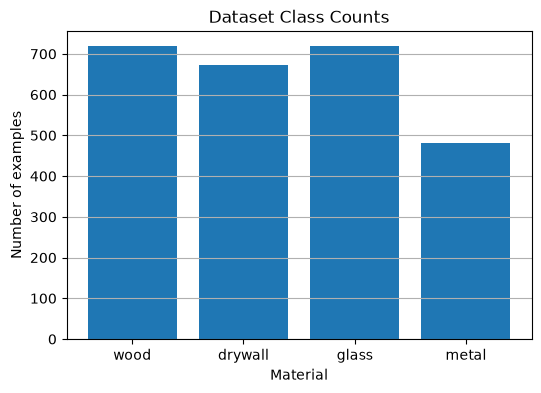

In [23]:

class_counts = [int(np.sum(dataset.y == i)) for i in range(len(dataset.materials))]

plt.figure(figsize=(6, 4))
plt.bar(dataset.materials, class_counts)
plt.xlabel("Material")
plt.ylabel("Number of examples")
plt.title("Dataset Class Counts")
plt.grid(axis="y")
plt.show()


# 9. Visualize Multipath Profiles

A multipath profile is the input to the model.

The x-axis below is sample index after downsampling. The y-axis is the normalized multipath value.


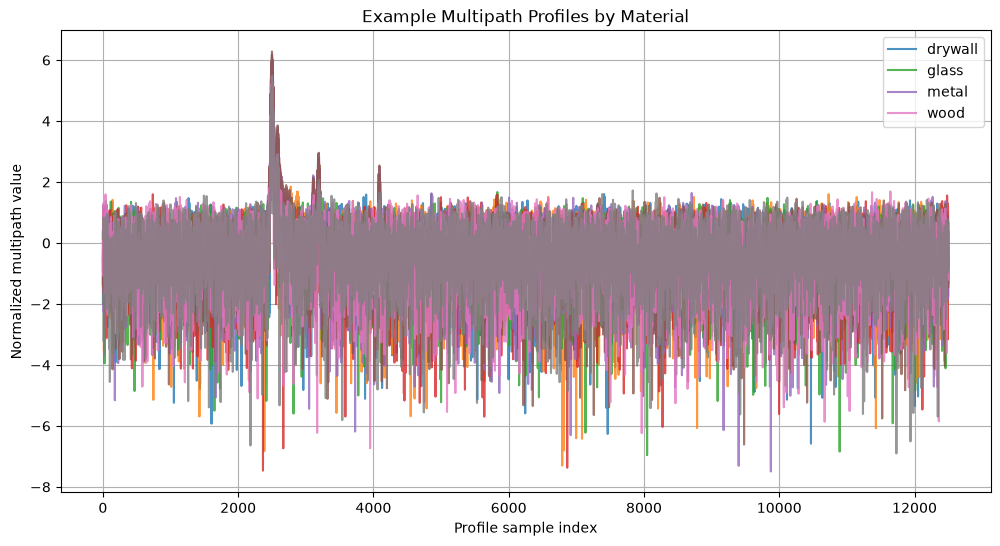

In [24]:

def plot_profiles_by_material(dataset: MultipathMaterialDataset, examples_per_class: int = 2):
    plt.figure(figsize=(12, 6))

    plotted = {m: 0 for m in dataset.materials}

    for idx in range(len(dataset)):
        sample = dataset[idx]
        material = sample["material"]

        if plotted[material] >= examples_per_class:
            continue

        profile = sample["profile"].squeeze(0).numpy()
        plt.plot(profile, alpha=0.8, label=material if plotted[material] == 0 else None)
        plotted[material] += 1

        if all(count >= examples_per_class for count in plotted.values()):
            break

    plt.xlabel("Profile sample index")
    plt.ylabel("Normalized multipath value")
    plt.title("Example Multipath Profiles by Material")
    plt.legend()
    plt.grid(True)
    plt.show()

plot_profiles_by_material(dataset, examples_per_class=2)


# 10. Train / Validation / Test Split

We will split the dataset into:

- training set
- validation set
- test set

To keep the class distribution reasonable, we will use a simple stratified split. That means each class is split separately.


In [25]:

def stratified_split_indices(
    labels: np.ndarray,
    train_ratio: float = 0.70,
    val_ratio: float = 0.15,
    seed: int = 42,
) -> Tuple[List[int], List[int], List[int]]:
    """Create train/validation/test indices while preserving class balance."""
    rng = random.Random(seed)

    train_indices = []
    val_indices = []
    test_indices = []

    labels = np.asarray(labels)
    classes = sorted(set(labels.tolist()))

    for cls in classes:
        cls_indices = np.where(labels == cls)[0].tolist()
        rng.shuffle(cls_indices)

        n = len(cls_indices)
        n_train = int(n * train_ratio)
        n_val = int(n * val_ratio)

        train_indices.extend(cls_indices[:n_train])
        val_indices.extend(cls_indices[n_train:n_train + n_val])
        test_indices.extend(cls_indices[n_train + n_val:])

    rng.shuffle(train_indices)
    rng.shuffle(val_indices)
    rng.shuffle(test_indices)

    return train_indices, val_indices, test_indices

train_idx, val_idx, test_idx = stratified_split_indices(dataset.y, seed=SEED)

train_dataset = Subset(dataset, train_idx)
val_dataset = Subset(dataset, val_idx)
test_dataset = Subset(dataset, test_idx)

print("Train examples:", len(train_dataset))
print("Validation examples:", len(val_dataset))
print("Test examples:", len(test_dataset))


Train examples: 1812
Validation examples: 388
Test examples: 392


# 11. DataLoaders

A `DataLoader` creates batches.

For this project, a batch of profiles will have shape:

```text
[batch_size, 1, number_of_samples]
```


In [ ]:

BATCH_SIZE = 32  # TODO: can try different values like 16, 32, or 64.

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

batch = next(iter(train_loader))

print("Batch profile shape:", batch["profile"].shape)
print("Batch aux shape:", batch["aux"].shape)
print("Batch label shape:", batch["label"].shape)
print("First labels:", batch["label"][:10])
print("First materials:", batch["material"][:10])


Batch profile shape: torch.Size([32, 1, 12501])
Batch aux shape: torch.Size([32, 4])
Batch label shape: torch.Size([32])
First labels: tensor([2, 3, 0, 1, 0, 1, 1, 1, 1, 3])
First materials: ['glass', 'metal', 'wood', 'drywall', 'wood', 'drywall', 'drywall', 'drywall', 'drywall', 'metal']


# 12. Build a Two-Branch CNN + MLP Model

This model has two branches that get fused before the final classifier:

```text
profile  → Conv1d → ReLU → MaxPool
         → Conv1d → ReLU → MaxPool
         → Conv1d → ReLU
         → Adaptive Average Pool          (profile branch, 32 features)

aux      → Linear → ReLU                  (aux branch, aux_hidden features)

[profile branch output, aux branch output] → concat → Linear classifier
```

The profile branch is the same small 1D CNN as before. The aux branch is a tiny
fully-connected layer over the per-example metadata (`v_angle`, `v_Power_Tx`, `K_dB`,
`PDP_RMS`). Their outputs are concatenated into one feature vector before the final
linear layer makes the material prediction.

`AdaptiveAvgPool1d(1)` still lets the profile branch work even if the profile length
changes, because it compresses the time/sample dimension down to one value per channel.


In [27]:

NUM_CLASSES = 4  # TODO: wood, drywall, glass, metal.
NUM_AUX_FEATURES = dataset.aux.shape[1]  # v_angle, v_Power_Tx, K_dB, PDP_RMS
AUX_HIDDEN = 16  # TODO: try a larger value if you add more aux features.

class MultipathAuxCNN(nn.Module):
    """1D CNN over the multipath profile, fused with a small MLP over scalar aux features."""

    def __init__(self, num_classes: int = 4, num_aux_features: int = 4, aux_hidden: int = 16):
        super().__init__()

        self.profile_branch = nn.Sequential(
            nn.Conv1d(in_channels=1, out_channels=8, kernel_size=9, padding=4),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=4),

            nn.Conv1d(in_channels=8, out_channels=16, kernel_size=9, padding=4),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=4),

            nn.Conv1d(in_channels=16, out_channels=32, kernel_size=9, padding=4),
            nn.ReLU(),

            nn.AdaptiveAvgPool1d(output_size=1),
            nn.Flatten(),
        )

        self.aux_branch = nn.Sequential(
            nn.Linear(num_aux_features, aux_hidden),
            nn.ReLU(),
        )

        self.classifier = nn.Linear(32 + aux_hidden, num_classes)

    def forward(self, x, aux):
        profile_features = self.profile_branch(x)   # [batch, 32]
        aux_features = self.aux_branch(aux)          # [batch, aux_hidden]
        combined = torch.cat([profile_features, aux_features], dim=1)
        return self.classifier(combined)

model = MultipathAuxCNN(
    num_classes=NUM_CLASSES,
    num_aux_features=NUM_AUX_FEATURES,
    aux_hidden=AUX_HIDDEN,
).to(device)

print(model)
print("Number of trainable parameters:", sum(p.numel() for p in model.parameters() if p.requires_grad))


MultipathAuxCNN(
  (profile_branch): Sequential(
    (0): Conv1d(1, 8, kernel_size=(9,), stride=(1,), padding=(4,))
    (1): ReLU()
    (2): MaxPool1d(kernel_size=4, stride=4, padding=0, dilation=1, ceil_mode=False)
    (3): Conv1d(8, 16, kernel_size=(9,), stride=(1,), padding=(4,))
    (4): ReLU()
    (5): MaxPool1d(kernel_size=4, stride=4, padding=0, dilation=1, ceil_mode=False)
    (6): Conv1d(16, 32, kernel_size=(9,), stride=(1,), padding=(4,))
    (7): ReLU()
    (8): AdaptiveAvgPool1d(output_size=1)
    (9): Flatten(start_dim=1, end_dim=-1)
  )
  (aux_branch): Sequential(
    (0): Linear(in_features=4, out_features=16, bias=True)
    (1): ReLU()
  )
  (classifier): Linear(in_features=48, out_features=4, bias=True)
)
Number of trainable parameters: 6164


## Test One Forward Pass

Before training, always pass one batch through the model to make sure the shapes work.


In [18]:

batch = next(iter(train_loader))

profiles = batch["profile"].to(device)
aux = batch["aux"].to(device)
labels = batch["label"].to(device)

logits = model(profiles, aux)

print("Input profile shape:", profiles.shape)
print("Input aux shape:", aux.shape)
print("Output logits shape:", logits.shape)
print("Label shape:", labels.shape)


Input profile shape: torch.Size([32, 1, 12501])
Input aux shape: torch.Size([32, 4])
Output logits shape: torch.Size([32, 4])
Label shape: torch.Size([32])


# 13. Loss Function and Optimizer

This is a classification problem, so we use `CrossEntropyLoss`.

The optimizer updates the model weights. We will use Adam because it is a good beginner default.


In [28]:

LEARNING_RATE = 1e-3  # TODO: try 1e-3 first.
EPOCHS = 10           # TODO: try 5 first, then 10 or 20.

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)


# 14. Training and Evaluation Functions

These functions are very similar to the training loop you used in Project 1.

The model learns only during `train_one_epoch`. During `evaluate`, the model is tested without updating weights.


In [29]:

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    total_loss = 0.0
    total_correct = 0
    total_examples = 0

    for batch in loader:
        profiles = batch["profile"].to(device)
        aux = batch["aux"].to(device)
        labels = batch["label"].to(device)

        logits = model(profiles, aux)
        loss = criterion(logits, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        batch_size = labels.size(0)
        total_loss += loss.item() * batch_size
        total_correct += (logits.argmax(dim=1) == labels).sum().item()
        total_examples += batch_size

    avg_loss = total_loss / total_examples
    avg_accuracy = total_correct / total_examples

    return avg_loss, avg_accuracy

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()

    total_loss = 0.0
    total_correct = 0
    total_examples = 0

    for batch in loader:
        profiles = batch["profile"].to(device)
        aux = batch["aux"].to(device)
        labels = batch["label"].to(device)

        logits = model(profiles, aux)
        loss = criterion(logits, labels)

        batch_size = labels.size(0)
        total_loss += loss.item() * batch_size
        total_correct += (logits.argmax(dim=1) == labels).sum().item()
        total_examples += batch_size

    avg_loss = total_loss / total_examples
    avg_accuracy = total_correct / total_examples

    return avg_loss, avg_accuracy


# 15. Train the Material Classifier



In [30]:

history = {
    "train_loss": [],
    "train_accuracy": [],
    "val_loss": [],
    "val_accuracy": [],
}

for epoch in range(EPOCHS):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)

    history["train_loss"].append(train_loss)
    history["train_accuracy"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_accuracy"].append(val_acc)

    print(
        f"Epoch {epoch + 1:02d}/{EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {100 * train_acc:.2f}% | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {100 * val_acc:.2f}%"
    )


Epoch 01/10 | Train Loss: 1.3675 | Train Acc: 28.04% | Val Loss: 1.3557 | Val Acc: 33.25%
Epoch 02/10 | Train Loss: 1.3344 | Train Acc: 34.60% | Val Loss: 1.3078 | Val Acc: 44.85%
Epoch 03/10 | Train Loss: 1.2452 | Train Acc: 44.59% | Val Loss: 1.1779 | Val Acc: 49.48%
Epoch 04/10 | Train Loss: 1.1001 | Train Acc: 51.60% | Val Loss: 1.0752 | Val Acc: 54.90%
Epoch 05/10 | Train Loss: 1.0038 | Train Acc: 55.79% | Val Loss: 1.0518 | Val Acc: 49.74%
Epoch 06/10 | Train Loss: 0.9783 | Train Acc: 55.35% | Val Loss: 0.9817 | Val Acc: 56.70%
Epoch 07/10 | Train Loss: 0.9372 | Train Acc: 57.40% | Val Loss: 0.9747 | Val Acc: 57.73%
Epoch 08/10 | Train Loss: 0.9236 | Train Acc: 58.89% | Val Loss: 0.9546 | Val Acc: 55.67%
Epoch 09/10 | Train Loss: 0.9080 | Train Acc: 59.00% | Val Loss: 0.9604 | Val Acc: 55.67%
Epoch 10/10 | Train Loss: 0.8946 | Train Acc: 59.66% | Val Loss: 0.9476 | Val Acc: 55.93%


# 16. Plot Training Curves


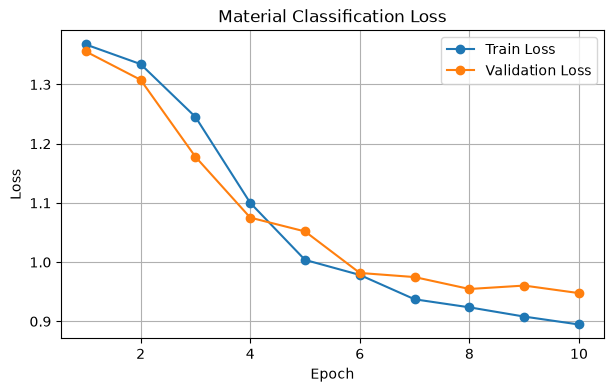

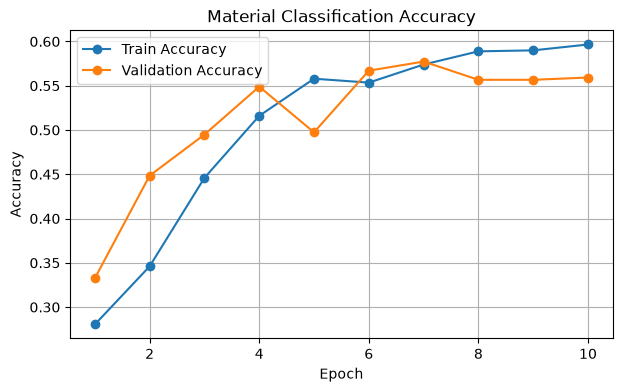

In [31]:

epochs = range(1, EPOCHS + 1)

plt.figure(figsize=(7, 4))
plt.plot(epochs, history["train_loss"], marker="o", label="Train Loss")
plt.plot(epochs, history["val_loss"], marker="o", label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Material Classification Loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(epochs, history["train_accuracy"], marker="o", label="Train Accuracy")
plt.plot(epochs, history["val_accuracy"], marker="o", label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Material Classification Accuracy")
plt.legend()
plt.grid(True)
plt.show()


# 17. Test the Model


In [33]:

test_loss, test_acc = evaluate(model, test_loader, criterion, device)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {100 * test_acc:.2f}%")


Test Loss: 0.9093
Test Accuracy: 61.73%


# 18. Confusion Matrix


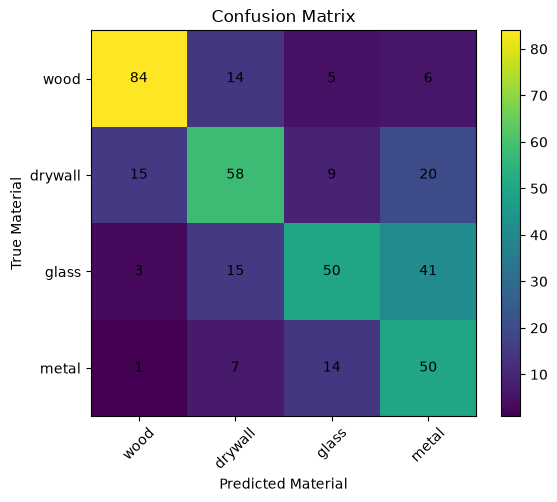

In [36]:

@torch.no_grad()
def collect_predictions(model, loader, device):
    model.eval()

    all_true = []
    all_pred = []

    for batch in loader:
        profiles = batch["profile"].to(device)
        aux = batch["aux"].to(device)
        labels = batch["label"].to(device)

        logits = model(profiles, aux)
        preds = logits.argmax(dim=1)

        all_true.extend(labels.cpu().numpy().tolist())
        all_pred.extend(preds.cpu().numpy().tolist())

    return np.asarray(all_true), np.asarray(all_pred)

def make_confusion_matrix(y_true, y_pred, num_classes):
    cm = np.zeros((num_classes, num_classes), dtype=int)

    for true_label, pred_label in zip(y_true, y_pred):
        cm[int(true_label), int(pred_label)] += 1

    return cm

y_true, y_pred = collect_predictions(model, test_loader, device)
cm = make_confusion_matrix(y_true, y_pred, num_classes=NUM_CLASSES)

#print(cm)

plt.figure(figsize=(6, 5))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Material")
plt.ylabel("True Material")
plt.xticks(range(NUM_CLASSES), dataset.materials, rotation=45)
plt.yticks(range(NUM_CLASSES), dataset.materials)

for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        plt.text(j, i, str(cm[i, j]), ha="center", va="center")

plt.colorbar()
plt.tight_layout()
plt.show()


# 19. Display Example Predictions

Here we plot a few multipath profiles and show the true material and predicted material.


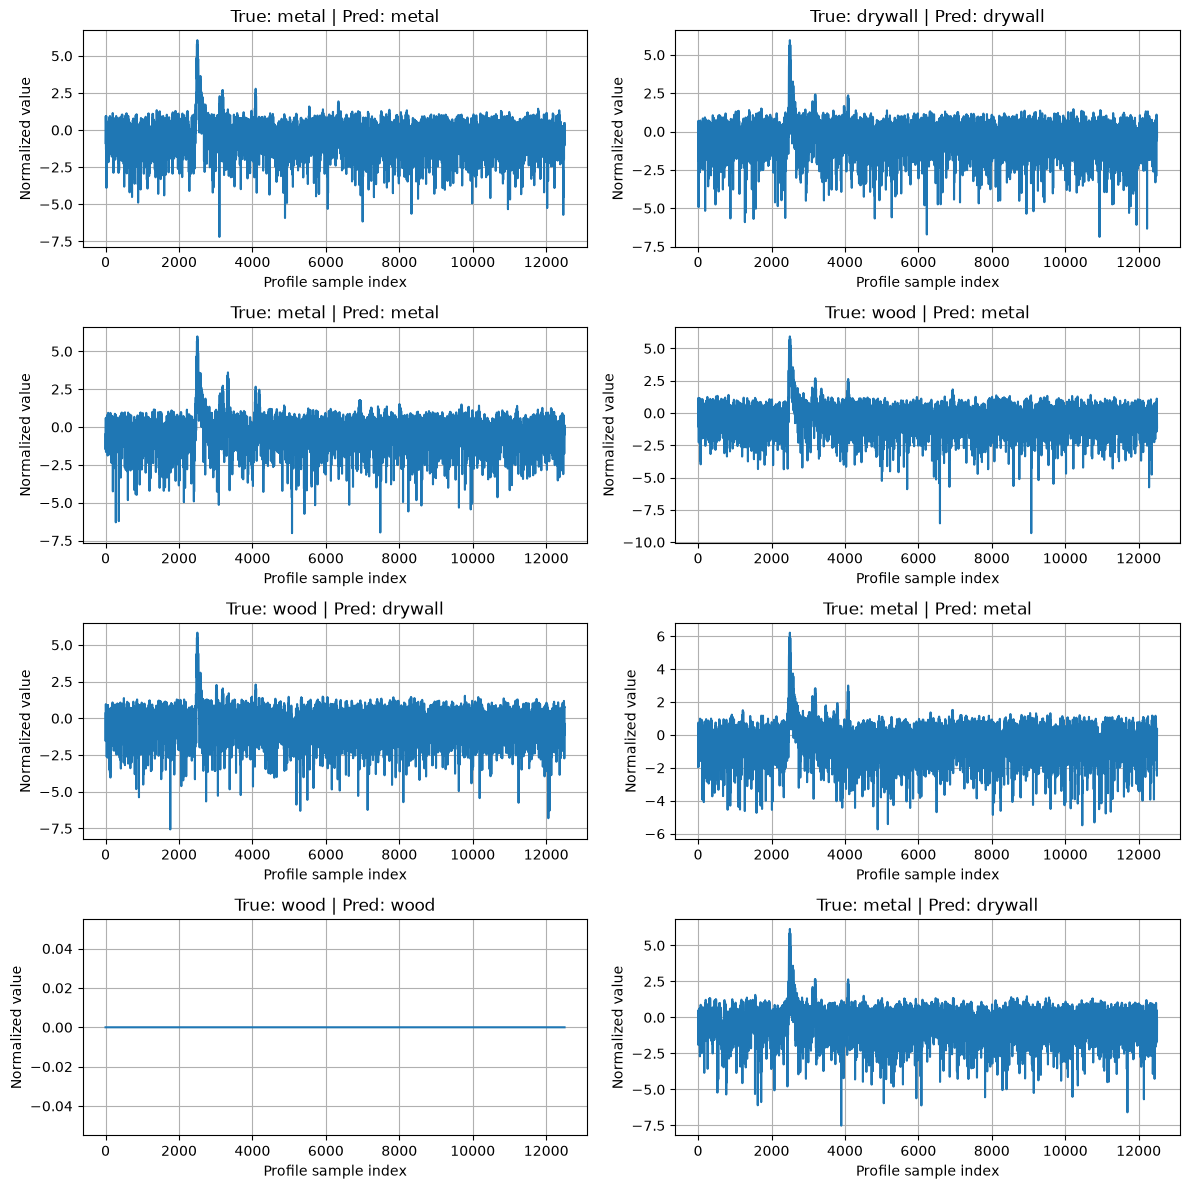

In [37]:

@torch.no_grad()
def show_prediction_examples(model, loader, dataset, device, n: int = 8):
    model.eval()

    batch = next(iter(loader))
    profiles = batch["profile"].to(device)
    aux = batch["aux"].to(device)
    labels = batch["label"]

    logits = model(profiles, aux)
    predictions = logits.argmax(dim=1).cpu()

    n = min(n, profiles.shape[0])
    rows = math.ceil(n / 2)

    plt.figure(figsize=(12, 3 * rows))

    for i in range(n):
        profile = batch["profile"][i].squeeze(0).numpy()
        true_label = int(labels[i])
        pred_label = int(predictions[i])

        true_name = dataset.label_to_material[true_label]
        pred_name = dataset.label_to_material[pred_label]

        plt.subplot(rows, 2, i + 1)
        plt.plot(profile)
        plt.title(f"True: {true_name} | Pred: {pred_name}")
        plt.xlabel("Profile sample index")
        plt.ylabel("Normalized value")
        plt.grid(True)

    plt.tight_layout()
    plt.show()

show_prediction_examples(model, test_loader, dataset, device, n=8)


# 20. Save the Model


In [27]:

MODEL_DIR = Path("models")
MODEL_DIR.mkdir(exist_ok=True)

model_path = MODEL_DIR / "p3_material_cnn.pt"

torch.save(
    {
        "model_state_dict": model.state_dict(),
        "materials": dataset.materials,
        "mp_key": MP_KEY,
        "profile_transform": PROFILE_TRANSFORM,
        "profile_stride": PROFILE_STRIDE,
        "aux_feature_names": dataset.aux_feature_names,
        "aux_mean": dataset.aux_mean,
        "aux_std": dataset.aux_std,
        "expected_profile_rows": dataset.expected_profile_rows,
        "skipped_row_mismatch": dataset.skipped_row_mismatch,
        "test_accuracy": test_acc,
    },
    model_path,
)

print("Saved model to:", model_path)
print(f"Skipped {len(dataset.skipped_row_mismatch)} files due to row-count mismatch")


Saved model to: models\p3_material_cnn.pt
Skipped 26 files due to row-count mismatch
